In [ ]:
run_on_colab = False
if run_on_colab:
    %rm -rf aptax
    !git clone https://github.com/antodima/aptax.git
    %cd aptax/
else:
    %cd ..

In [2]:
from collections import defaultdict
from tqdm import tqdm
from pathlib import Path

from transformers import AutoTokenizer

import jax
import jax.numpy as jnp
from jax.sharding import SingleDeviceSharding 

import flax.nnx as nnx
from flax.training.early_stopping import EarlyStopping

import optax
import orbax
from orbax import checkpoint

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from aptax.llm import MiniGPT
from aptax.dataset import create_dataloader
from aptax.dataset import load_stories, TextsDataset

In [3]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
vocab_size = tokenizer.vocab_size

max_seq_len = 256
embed_dim = 192
num_heads = 6
batch_size = 32
num_transformer_blocks = 6
num_epochs = 1000

texts = load_stories()

dataset = TextsDataset(texts, max_seq_len, tokenizer)
dataloader, batches_per_epoch = create_dataloader(dataset, batch_size=batch_size, num_epochs=1)
total_steps = num_epochs * batches_per_epoch
warmup_steps = max(1, total_steps // 10)
print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {batches_per_epoch}")
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Loading stories from aptax/data/tinystories/TinyStories-1000.txt...
Loaded 1,000 stories
Dataset size: 1000
Batches per epoch: 31
Total training steps: 31,000
Warmup steps: 3,100


In [4]:
model = MiniGPT(
    max_seq_len=max_seq_len,
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_transformer_blocks=num_transformer_blocks,
    rngs=nnx.Rngs(0),
)
print(model)

MiniGPT( # RngState: 2 (12 B), Param: 20,237,184 (80.9 MB), Total: 20,237,186 (80.9 MB)
  max_seq_len=256,
  embedding=TokenAndPositionEmbedding( # Param: 9,698,496 (38.8 MB)
    token_emb=Embed( # Param: 9,649,344 (38.6 MB)
      embedding=Param( # 9,649,344 (38.6 MB)
        value=Array(shape=(50257, 192), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x791b5bfa37e0>
    ),
    pos_emb=Embed( # Param: 49,152 (196.6 KB)
      embedding=Param( # 49,152 (196.6 KB)
        value=Array(shape=(256, 192), dtype=dtype('float32'))
      ),
      num_embeddings=256,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      promote_dtype=<function promote_dtype at 0x791b5bfa37e0>
    )
  ),
  transformer_blocks=[TransformerBlock( # Param: 148,224 (592.9 KB)
    attn=MultiHeadAttention( # Param: 148,224 (592.9 KB)
      num_heads=6,
 

In [5]:
def loss_fn(model, batch):
    inputs, targets, mask = batch
    logits = model(inputs)
    full_loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets)
    masked_loss = full_loss * mask
    loss = jnp.sum(masked_loss) / jnp.sum(mask)
    return loss, logits


@nnx.jit
def train_step(model, optimizer, metrics, batch):
    inputs, targets, mask = batch
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=targets)
    optimizer.update(grads)


def eval_step(model, metrics, batch):
    inputs, targets, mask = batch
    loss, logits = loss_fn(model, batch)
    metrics.update(loss=loss, logits=logits, labels=targets)


lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=5e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=5e-5,
)
optimizer = nnx.ModelAndOptimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01),
)
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average("loss"),
)

In [6]:
step = 0
score_history = defaultdict(list)
early_stop = EarlyStopping(min_delta=1e-2, patience=5)
for epoch in range(num_epochs):
    epoch_history = defaultdict(list)
    train_batches, test_batches = train_test_split(
        list(range(batches_per_epoch)), test_size=0.2, random_state=epoch
    )
    batch_idx = 0
    for batch in (pbar := tqdm(dataloader, total=batches_per_epoch)):
        inputs = jnp.array(batch["inputs"]).T
        labels = jnp.array(batch["labels"]).T
        loss_mask = jnp.array(batch["loss_mask"]).T

        step_type = "train" if batch_idx in train_batches else "valid"
        if step_type == "train":
            train_step(model, optimizer, metrics, (inputs, labels, loss_mask))
        else:
            eval_step(model, metrics, (inputs, labels, loss_mask))

        for metric, value in metrics.compute().items():
            epoch_history[f"{step_type}_{metric}"].append(value)
        metrics.reset()

        current_lr = lr_schedule(step)
        pbar.set_description(
            f"epoch: {epoch + 1}/{num_epochs}, lr: {current_lr:.2e}, "
            f"loss (train): {np.mean(epoch_history['train_loss']):.3f}, "
            f"loss (valid): {np.mean(epoch_history['valid_loss']):.3f}, "
        )
        step += 1
        batch_idx += 1

    for metric, values in epoch_history.items():
        score_history[metric].append(values)
    early_stop = early_stop.update(np.mean(score_history["train_loss"]))
    if early_stop.should_stop:
        print(f"\nMet early stopping criteria! Breaking at epoch {epoch}.")
        break

  0%|          | 0/31 [00:00<?, ?it/s]/teamspace/studios/this_studio/aptax/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/teamspace/studios/this_studio/aptax/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
epoch: 1/1000, lr: 4.84e-06, loss (train): 10.880, loss (valid): 10.871, : 100%|██████████| 31/31 [00:23<00:00,  1.31it/s]
epoch: 2/1000, lr: 9.84e-06, loss (train): 10.839, loss (valid): 10.819, : 100%|██████████| 31/31 [00:09<00:00,  3.34it/s]
epoch: 3/1000, lr: 1.48e-05, loss (train): 10.762, loss (valid): 10.763, : 100%|██████████| 31/31 [00:09<00:00,  3.11it/s]
epoch: 4/1000, lr: 1.98e-05, loss (train): 10.624, loss (valid): 10.599, : 100%|██████████| 31/31 [00:11<00:00,  2.80it/s]
epoch: 5/1000, lr: 2.48e-05, loss (train): 10.318, loss (valid): 10.286, : 100%|█


Met early stopping criteria! Breaking at epoch 800.


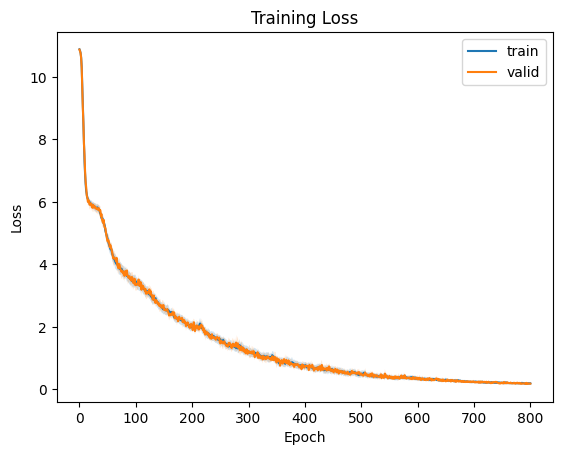

In [7]:
train_loss = np.array(score_history['train_loss'])
valid_loss = np.array(score_history['valid_loss'])

plt.plot(train_loss.mean(axis=1), label='train')
plt.fill_between(
    np.arange(0, len(train_loss)), 
    np.subtract(train_loss.mean(axis=1), train_loss.std(axis=1)), 
    np.add(train_loss.mean(axis=1), train_loss.std(axis=1)), 
    alpha=0.2, 
    linestyle='-',
)
plt.plot(valid_loss.mean(axis=1), label='valid')
plt.fill_between(
    np.arange(0, len(valid_loss)), 
    np.subtract(valid_loss.mean(axis=1), valid_loss.std(axis=1)), 
    np.add(valid_loss.mean(axis=1), valid_loss.std(axis=1)), 
    alpha=0.2, 
    linestyle='-',
)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [8]:
checkpoint_path = Path.cwd() / "checkpoints" / "minigpt.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()
checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")
if run_on_colab:
    !zip -r minigpt.orbax.zip $checkpoint_path

Model saved as /teamspace/studios/this_studio/aptax/checkpoints/minigpt.orbax


In [9]:
checkpoint_path = Path.cwd() / "checkpoints" / "minigpt.orbax"
checkpointer = orbax.checkpoint.PyTreeCheckpointer()

cpu_device = jax.devices('cpu')[0]
cpu_sharding = SingleDeviceSharding(cpu_device)
restore_args = jax.tree_util.tree_map(
    lambda _: checkpoint.ArrayRestoreArgs(sharding=cpu_sharding),
    nnx.state(model)
)
nnx.state(model)
restored_state = checkpointer.restore(
    checkpoint_path,
    item=nnx.state(model),
    restore_args=restore_args)

nnx.update(model, restored_state)

In [11]:
def generate_text(model, start_tokens, max_new_tokens=50, temperature=1.0):
    tokens = list(start_tokens)
    for _ in range(max_new_tokens):
        context = tokens[-model.max_seq_len:]
        # RIGHT-pad to match training (not left-pad!)
        actual_len = len(context)
        if actual_len < model.max_seq_len:
            context = context + [0] * (model.max_seq_len - actual_len)

        context_array = jnp.atleast_2d(jnp.array(context))
        logits = model(context_array)
        next_token_logits = logits[0, actual_len - 1, :] / temperature
        next_token = int(jnp.argmax(next_token_logits))
        if next_token == tokenizer.encode(dataset.eot_token)[0]:
            break
        tokens.append(next_token)
    return tokenizer.decode(tokens)

def generate_story(model, story_prompt, temperature, max_new_tokens):
    start_tokens = tokenizer.encode(story_prompt)[:model.max_seq_len]
    generated = generate_text(model, start_tokens, max_new_tokens=max_new_tokens, temperature=temperature)
    return generated

def create_story(story_prompt, temperature, max_new_tokens):
    return generate_story(model, story_prompt, temperature, max_new_tokens)

create_story("Once upon a time", 0.2, 50)

'Once upon a time, there was a little girl named Lily. She loved to play with her toys and run around outside. One day, her mom asked her to clean her room upstairs. Her mom said, "L, I have ready to clean it\'s toys tidy'